# DeepLense Task V

For this task we use the same base pipeline from Test I.

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Import packages
import numpy as np
import torch
from torch import nn
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from pathlib import Path
import matplotlib.pyplot as plt

## Dataset

A dataset comprising observational data of strong lenses and non-lensed galaxies. Images in three different filters are available for each object, so the shape of each object array is (3, 64, 64). Lensed objects are placed in the directory train_lenses and test_lenses, non-lensed galaxies are in train_nonlenses and test_nonlenses.

In [3]:
# Download provided dataset
# !gdown "https://drive.google.com/uc?id=1doUhVoq1-c9pamZVLpvjW1YRDMkKO1Q5" -O dataset_test_V.zip
# !mkdir -p dataset_test_V
# !unzip dataset_test_V.zip -d dataset_test_V

In [4]:
# Dataset class
class DeepLenseDataset(Dataset):

    CLASS_NAMES = ["nonlenses", "lenses"]

    def __init__(self, path: str, transform: transforms.Compose = None):

        self.root = path
        self.samples = []
        self.idx_to_class = {i: name for i, name in enumerate(self.CLASS_NAMES)}
        self.transform = transform

        for class_idx, class_name in enumerate(self.CLASS_NAMES):
            class_dir = Path(self.root + class_name)
            paths = class_dir.glob("*.npy")
            self.samples.extend((p, class_idx) for p in paths)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> tuple[Tensor, int]:
        path, label = self.samples[idx]
        arr = np.load(path)
        x = torch.from_numpy(arr).float()
        if self.transform:
            x = self.transform(x)
        return x, label


In [5]:
# Load datasets
train_dataset = DeepLenseDataset(path="dataset_test_V/train_")
test_dataset = DeepLenseDataset(path="dataset_test_V/test_")

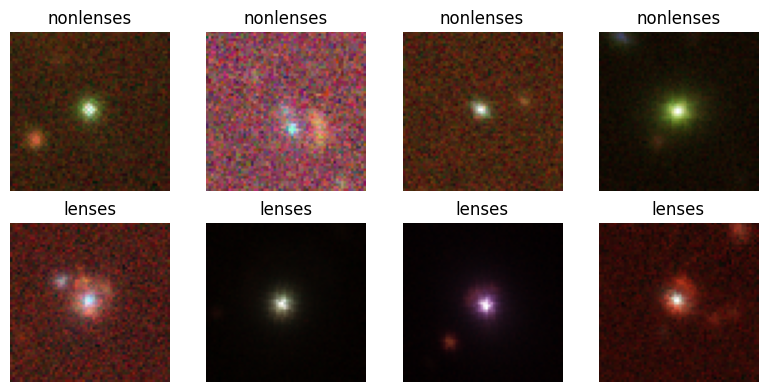

In [6]:
def plot_sample(x, y, figsize=(4, 4)):
    """
    Plot a sample from the dataset.
    """
    img = x.squeeze().detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"label={y}")
    plt.show()

def inspect_dataset(dataset: DeepLenseDataset):
    """
    Iterate over the dataset and plot 4 samples for each class.
    """

    count = {}
    count_total = 0

    fig, axs = plt.subplots(2, 4, figsize=(8, 4))
    axs = axs.flatten()

    for i in range(len(dataset)):

        x, y = dataset[i]

        if count.get(y, 0) < 4:
            img = img = x.squeeze().detach().cpu().numpy()
            img = np.transpose(img, (1, 2, 0))
            axs[count_total].imshow(img)
            axs[count_total].set_title(dataset.idx_to_class[y])
            axs[count_total].axis("off")
            count[y] = count.get(y, 0) + 1
            count_total += 1

    plt.tight_layout()
    plt.show()

# Visualize some samples
inspect_dataset(train_dataset)

[28675, 1730]


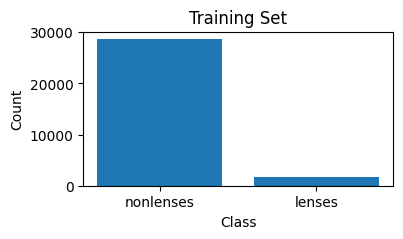

[19455, 195]


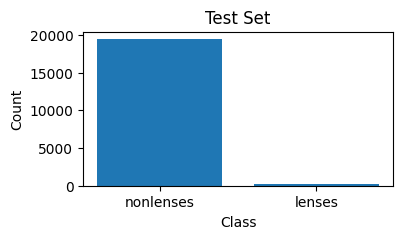

In [7]:
def plot_class_distribution(dataset, title="Class Distribution"):
    """
    Plot dataset class distribution.
    """
    labels = [dataset.idx_to_class[i] for i in range(len(dataset.idx_to_class))]
    counts = [0] * len(labels)
    for _, y in dataset:
        counts[y] += 1

    print(counts)

    plt.figure(figsize=(4,2))
    plt.bar(labels, counts)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

# Plot class distribution
plot_class_distribution(train_dataset, "Training Set")
plot_class_distribution(test_dataset, "Test Set")

We can see that the dataset is highly unbalanced.

In [8]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

def stratified_split(dataset, transform=None, train_size=0.8):

    # Get labels
    labels = [label for _, label in dataset]

    # Stratified split
    train_indices, val_indices = train_test_split(
        np.arange(len(labels)),
        train_size=train_size,
        stratify=labels,
        random_state=42
    )

    # Create train and val datasets
    # Augmentation is applied to training dataset only
    train_ds = DeepLenseDataset(path=dataset.root, transform=transform)
    val_ds = DeepLenseDataset(path=dataset.root, transform=None)
    train_dataset = Subset(train_ds, train_indices)
    val_dataset = Subset(val_ds, val_indices)

    return train_dataset, val_dataset

A stratified split is specially required here as we have an unbalanced dataset.

## Dataloader

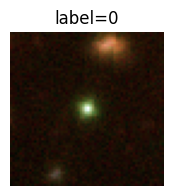

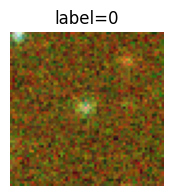

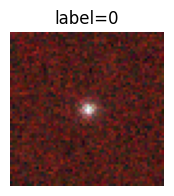

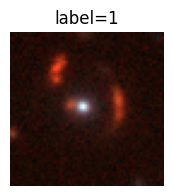

In [9]:
# Create dataloader
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Iterate over the dataloader
for x, y in train_dataloader:
    for i in range(x.shape[0]):
        plot_sample(x[i], y[i], figsize=(2, 2))
    break


## Training

- I am using PyTorch Lightning for training to avoid writing standard boilerplate code.

- I am using data from "train" folders for training and validation (80 : 20 stratified split)

- The "test" data will be used for reporting final results only.

- The base training pipeline for this task is straightforward:

  - Resnet18
  - Binary Cross Entropy Loss
  - Adam optimizer
  - ReduceLROnPlateau (if validation loss doesn't improve by 5 epochs)
  - Early Stopping (if validation loss doesn't improve by 10 epochs)
  - Save best checkpoint based on validation loss

- To allow for rapid iteration, I will use small models. The models are imported from torchvision with weights pretrained on ImageNet and final layer is modified to match the required number of classes.

- Experimental results:

  | Name | val_loss | val_auroc | val_acc | val_f1 (0.5) | val_f1 (optimal) |
  | :--- | :--- | :--- | :--- | :--- | :--- |
  | resnet18 + oversampling + affine + noise (0.01) | 0.0641 | 0.9809 | 0.9880 | 0.8288 | 0.8744 (0.9009) |
   | resnet18 + oversampling + affine + noise (0.05) | 0.1455 | 0.9383 | 0.9765 | 0.6185 | 0.7120 (0.8217) |
  | resnet18 + oversampling + affine | 0.0587 | 0.9775 | 0.9946 | 0.8268 | 0.8617 (0.8811) |
  | resnet18 + oversampling | 0.0802 | 0.9801 | 0.9827 | 0.8259 | 0.8259 (0.4951) |
  | resnet18 | 0.0571 | 0.9791 | 0.9889 | 0.7968 | 0.8379 (0.1783) |
  | resnet18 + pos_weight | 0.3163 | 0.9530 | 0.9832 | 0.6925 | 0.7972 (0.9504) |

  <b>Train Loss</b><br><img src="images/test_V_train_loss.png" alt="train loss" width="800"/>

  <b>Validation Loss</b><br><img src="images/test_V_val_loss.png" alt="val loss" width="800"/>

  <b>Validation F1 Score</b><br><img src="images/test_V_val_f1.png" alt="val f1" width="800"/>

In [10]:
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from torch.utils.data import WeightedRandomSampler
from pytorch_lightning.loggers import TensorBoardLogger

class DeepLenseModel(pl.LightningModule):

    def __init__(self, threshold=0.5, lr=0.001, pos_weight=None):

        super().__init__()
        self.lr = lr
        self.loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.model = models.resnet18(weights="DEFAULT")
        self.model.fc = nn.Linear(self.model.fc.in_features, 1)

        # Metrics
        self.accuracy = torchmetrics.classification.BinaryAccuracy(threshold=threshold)
        self.f1 = torchmetrics.classification.BinaryF1Score(threshold=threshold)
        self.auroc = torchmetrics.classification.BinaryAUROC()
        self.roc = torchmetrics.classification.BinaryROC()
        self.cm = torchmetrics.classification.BinaryConfusionMatrix(threshold=threshold)

    def forward(self, x):
        return self.model(x).squeeze(-1)

    # Run every training step
    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss_fn(preds, y.float())
        self.log("train_loss", loss, prog_bar=True)
        return loss

    # Run every validation step
    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss_fn(preds, y.float())

        probs = torch.sigmoid(preds)
        self.auroc(probs, y)
        self.roc(probs, y)
        self.accuracy(probs, y)
        self.f1(probs, y)
        self.cm(probs, y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_auroc", self.auroc, prog_bar=True, on_epoch=True)
        self.log("val_acc", self.accuracy, prog_bar=True, on_epoch=True)
        self.log("val_f1", self.f1, prog_bar=True, on_epoch=True)

        return loss

    # Run after validation
    def on_validation_epoch_end(self):
        if self.trainer.sanity_checking:
            return

        # Compute ROC
        fpr, tpr, thresholds = self.roc.compute()
        self.last_fpr = fpr.detach().cpu()
        self.last_tpr = tpr.detach().cpu()
        self.roc.reset()

        # Compute confusion matrix
        self.confusion_matrix = self.cm.compute().detach().cpu()
        self.cm.reset()

        # Reset metrics
        self.auroc.reset()
        self.accuracy.reset()
        self.f1.reset()

    def configure_optimizers(self):

        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.1,
            patience=5
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1
            }
        }

# Augmentations
def add_per_channel_noise(tensor):
    noise = torch.randn_like(tensor) * 0.01
    return tensor + noise

transform = transforms.Compose([
    transforms.Lambda(add_per_channel_noise),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

# Initialize dataloaders
BATCH_SIZE = 128

# Split dataset into train and validation
dataset = DeepLenseDataset(path="dataset_test_V/train_")
train_dataset, val_dataset = stratified_split(dataset, train_size=0.8, transform=transform)

# # Compute weight for loss
# labels = torch.tensor([label for _, label in train_dataset])
# num_pos = torch.sum(labels == 1)
# num_neg = torch.sum(labels == 0)
# pos_weight = num_neg / num_pos
# print(f"Positive weight: {pos_weight.item():.4f}")

# Oversampling
labels = torch.tensor([label for _, label in train_dataset])
counts = torch.tensor([torch.sum(labels == 0), torch.sum(labels == 1)])
weight = 1.0 / counts.float()
samples_weight = torch.tensor([weight[label] for label in labels])
print("Sample weights: ", samples_weight)

sampler = WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    # shuffle=True,
    sampler=sampler
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Initialize model
model = DeepLenseModel()

# Train
logger = TensorBoardLogger(
    save_dir="logs",
    name="test_V",
    version="resnet18 + oversampling + affine + noise (0.01)"
)

trainer = pl.Trainer(
    max_epochs=60,
    accelerator="auto",
    logger=logger,
    callbacks=[
        # Save the best model based on validation loss
        ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1),
        # Stop training if validation loss does not improve for 10 epochs
        EarlyStopping(monitor="val_loss", patience=10, mode="min")
    ]
)

# Uncomment to train
trainer.fit(model, train_dataloader, val_dataloader)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Sample weights:  tensor([4.3592e-05, 4.3592e-05, 4.3592e-05,  ..., 4.3592e-05, 4.3592e-05,
        4.3592e-05])



  | Name     | Type                  | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss_fn  | BCEWithLogitsLoss     | 0      | train | 0    
1 | model    | ResNet                | 11.2 M | train | 0    
2 | accuracy | BinaryAccuracy        | 0      | train | 0    
3 | f1       | BinaryF1Score         | 0      | train | 0    
4 | auroc    | BinaryAUROC           | 0      | train | 0    
5 | roc      | BinaryROC             | 0      | train | 0    
6 | cm       | BinaryConfusionMatrix | 0      | train | 0    
-------------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.708    Total estimated model params size (MB)
74        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 31: 100%|██████████| 191/191 [00:33<00:00,  5.76it/s, v_num=.01), train_loss=1.250, val_loss=0.0959, val_auroc=0.989, val_acc=0.967, val_f1=0.764]  


In [11]:
# Print results on validation data
val_results = trainer.validate(model, val_dataloader, ckpt_path="best")

Restoring states from the checkpoint path at logs/test_V/resnet18 + oversampling + affine + noise (0.01)/checkpoints/epoch=21-step=4202.ckpt
Loaded model weights from the checkpoint at logs/test_V/resnet18 + oversampling + affine + noise (0.01)/checkpoints/epoch=21-step=4202.ckpt
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Validation DataLoader 0: 100%|██████████| 48/48 [00:04<00:00, 11.84it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.9702351689338684
        val_auroc           0.9890893697738647
         val_f1             0.7779141068458557
        val_loss            0.07221586257219315
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


The F1 score being computed so far is using a default threshold of 0.5.

Let's use the validation data to tune the classification threshold.

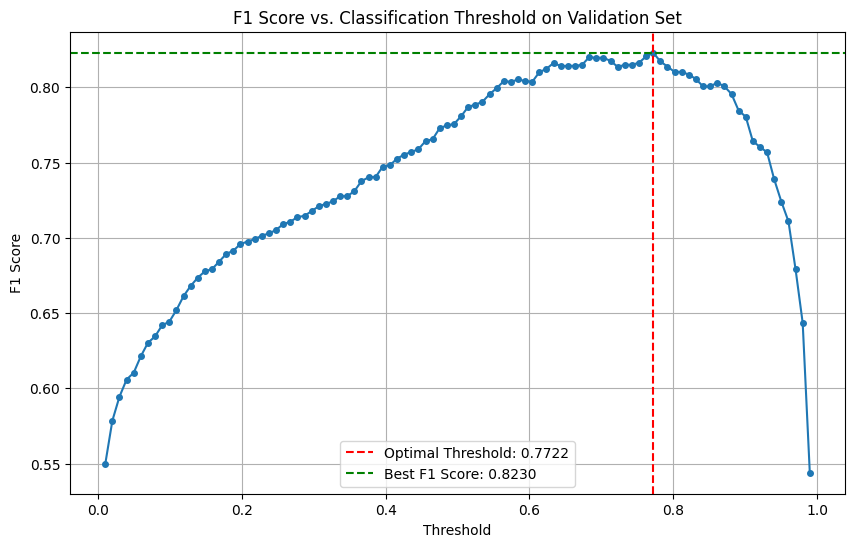

In [12]:
import torch.nn.functional as F

# Function to get all predictions (logits) and true labels from a dataloader
def get_all_preds_and_labels(trainer_instance, model_instance, dataloader_instance):
    model_instance.eval() # Set model to evaluation mode
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader_instance:
            x, y = batch
            # Move data to the same device as the model
            x = x.to(model_instance.device)
            y = y.to(model_instance.device)

            logits = model_instance(x)
            all_logits.append(logits.cpu())
            all_labels.append(y.cpu())

    return torch.cat(all_logits), torch.cat(all_labels)

val_logits, val_labels_tensor = get_all_preds_and_labels(trainer, model, val_dataloader)
val_probs = F.sigmoid(val_logits)

# Define a range of thresholds
thresholds = torch.linspace(0.01, 0.99, 100)
f1_scores = []
binary_f1 = torchmetrics.classification.BinaryF1Score()

# Calculate F1 score for each threshold
best_f1_score = -1
optimal_threshold = 0.5

for t in thresholds:
    binary_preds = (val_probs >= t).int()
    f1 = binary_f1(binary_preds, val_labels_tensor)
    f1_scores.append(f1.item())

    if f1 > best_f1_score:
        best_f1_score = f1
        optimal_threshold = t

# Plot F1 scores vs thresholds
plt.figure(figsize=(10, 6))
plt.plot(thresholds.numpy(), f1_scores, marker='o', linestyle='-', markersize=4)
plt.title('F1 Score vs. Classification Threshold on Validation Set')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.grid(True)
plt.axvline(x=optimal_threshold.item(), color='r', linestyle='--', label=f'Optimal Threshold: {optimal_threshold.item():.4f}')
plt.axhline(y=best_f1_score.item(), color='g', linestyle='--', label=f'Best F1 Score: {best_f1_score.item():.4f}')
plt.legend()
plt.show()

In [13]:
# Print results with tuned threshold
model.f1.threshold = optimal_threshold
model.accuracy.threshold = optimal_threshold
model.cm.threshold = optimal_threshold
val_results = trainer.validate(model, val_dataloader, ckpt_path="best")

Restoring states from the checkpoint path at logs/test_V/resnet18 + oversampling + affine + noise (0.01)/checkpoints/epoch=21-step=4202.ckpt
Loaded model weights from the checkpoint at logs/test_V/resnet18 + oversampling + affine + noise (0.01)/checkpoints/epoch=21-step=4202.ckpt
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Validation DataLoader 0: 100%|██████████| 48/48 [00:03<00:00, 13.23it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.9802663922309875
        val_auroc           0.9890893697738647
         val_f1             0.8230088353157043
        val_loss            0.07221586257219315
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


## Test

- Following good practices in Machine Learning, this step is performed once after selecting the best model. This way, we avoid overfitting to the test data.

In [17]:
ckpt_path = "weights/test_V_best_model.ckpt"

# Load model with optimal classification threshold
model = DeepLenseModel.load_from_checkpoint(ckpt_path)
optimal_threshold = 0.8230
model.f1.threshold = optimal_threshold
model.accuracy.threshold = optimal_threshold
model.cm.threshold = optimal_threshold

# Load test data
test_dataset = DeepLenseDataset(path="dataset_test_V/test_")
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Run
test_results = trainer.validate(model, test_dataloader)


/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Validation DataLoader 0:   1%|▏         | 2/154 [00:00<00:08, 18.19it/s]

/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)


Validation DataLoader 0: 100%|██████████| 154/154 [00:09<00:00, 15.48it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.9887022972106934
        val_auroc           0.9790099859237671
         val_f1             0.5779467821121216
        val_loss            0.06314817070960999
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


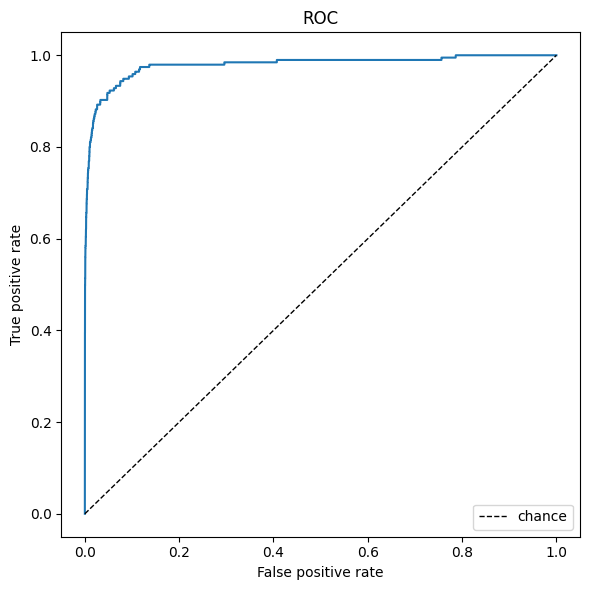

In [15]:
def plot_roc(model):

    # Get ROC results
    fprs = model.last_fpr
    tprs = model.last_tpr

    # Plot curves
    plt.figure(figsize=(6, 6))
    plt.plot(
        np.asarray(fprs).ravel(),
        np.asarray(tprs).ravel(),
    )

    plt.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

plot_roc(model)

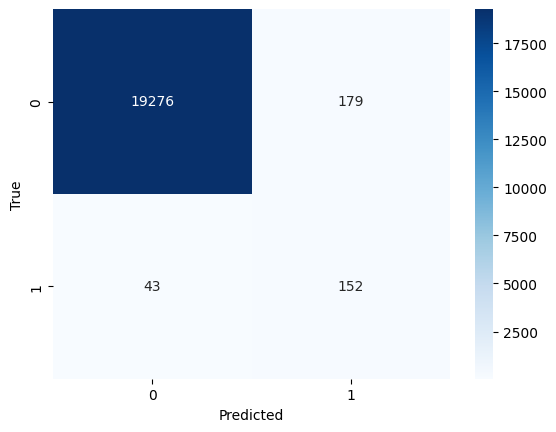

In [16]:
import seaborn as sns

def plot_confusion_matrix(model):
    sns.heatmap(model.confusion_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_confusion_matrix(model)